# Task 2: Credit Risk Prediction

## Problem Statement
Predict whether a loan applicant is likely to default on a loan using the
Loan Prediction Dataset. We use Logistic Regression for binary classification.

## Dataset
- Source: Kaggle Loan Prediction Dataset
- Rows: 614 | Columns: 13
- Target: Loan_Status (Y = Approved, N = Rejected)

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay



In [61]:
df = pd.read_csv("/content/train.csv")
# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()



Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## **Handle Missing Values**

In [41]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [42]:
# Fill categorical columns with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns with median
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col] = df[col].fillna(df[col].median())


print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## **Visualize Key Features**




/tmp/ipykernel_757/2570239646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='Set2')


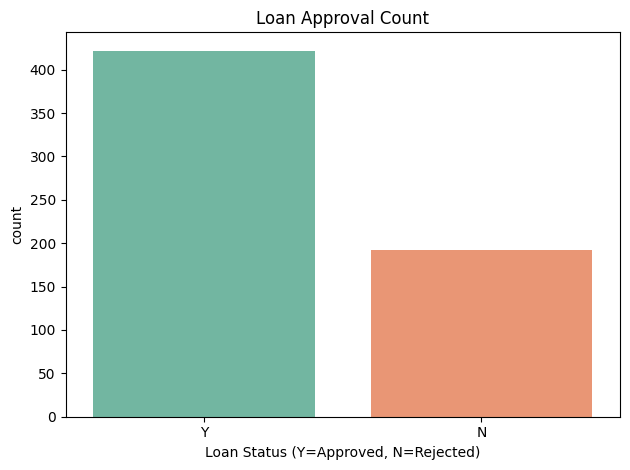

In [43]:
# 1. Loan Status Count — approved vs rejected
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title('Loan Approval Count')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.tight_layout()
plt.show()

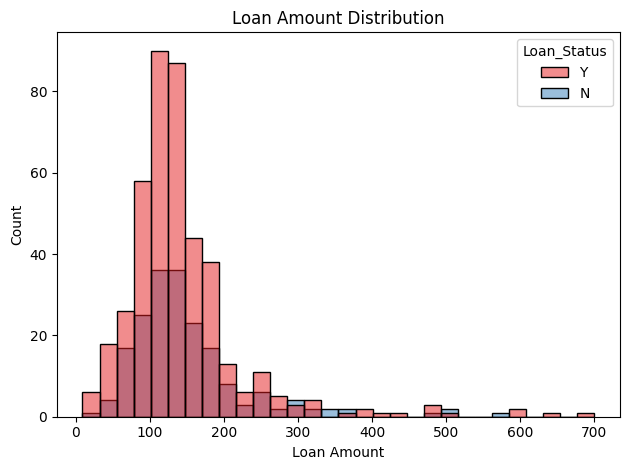

In [44]:
# 2. Loan Amount Distribution
sns.histplot(data=df, x='LoanAmount', hue='Loan_Status', bins=30, palette='Set1')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.tight_layout()
plt.show()

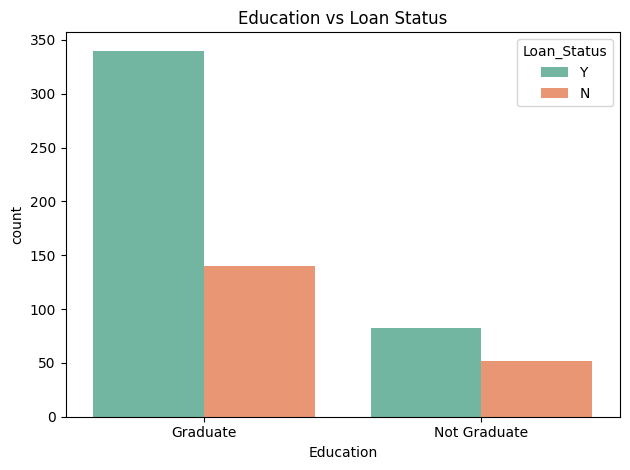

In [45]:
# 3. Education vs Loan Status
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set2')
plt.title('Education vs Loan Status')
plt.tight_layout()
plt.show()

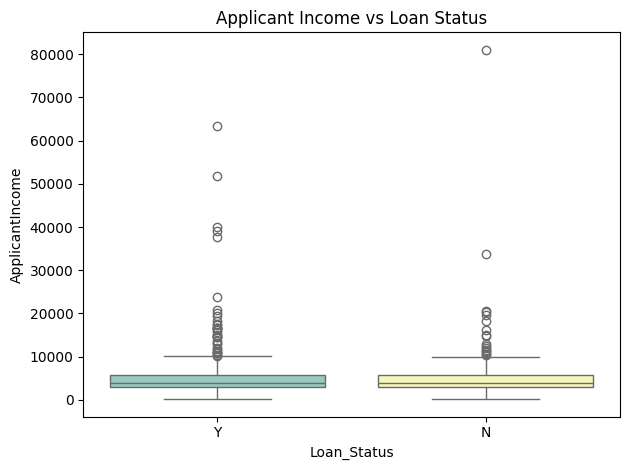

In [46]:
# Applicant Income vs Loan Status
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', hue='Loan_Status', legend=False, palette='Set3')
plt.title('Applicant Income vs Loan Status')
plt.tight_layout()
plt.show()

##  **Encode Categorical Columns**

In [51]:
# convert the Categorical values into Numerical so that ML model can learn it
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
  df[col] = le.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# **Model Training**

In [54]:

# Separate Input and Output Features
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Split 80% data for triaing and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Training target size:", y_train.shape)
print("Testing target size:", y_test.shape)


Training size: (491, 11)
Testing size: (123, 11)
Training target size: (491,)
Testing target size: (123,)


In [57]:

# Scale features — brings all values to same range, helps model converge faster
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train again with higher max_iter
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# **Evaluate the Model**

Accuracy: 0.7886178861788617


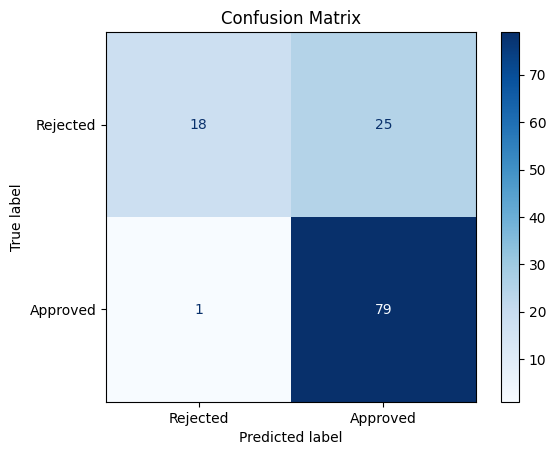

In [58]:
# prediction on test data
y_pred = model.predict(X_test)

# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
accuracy = accuracy_score(y_test, y_pred)



# Conclusion

- Dataset had missing values which were handled using median and mode.
- After encoding and scaling, Logistic Regression was trained on 80% data.
- Model achieved **78.86% accuracy** on test data.
- Model correctly identified 79 approved and 18 rejected loans.
- 25 rejected loans were misclassified as approved — likely due to class imbalance.
- Credit history and income are key factors in loan approval prediction.